# Proyek Analisis Data: Bike Sharing Dataset
- **Nama:** Jacky Sakti Pratama
- **Email:** jackysaktilim@gmail.com
- **ID Dicoding:** jackysaktipratama

## Menentukan Pertanyaan Bisnis

- Bagaimana perbedaan tren jam sibuk (peak hours) penyewaan sepeda antara pengguna casual dan registered pada hari kerja dibandingkan dengan akhir pekan/hari libur selama periode tahun 2011 hingga 2012, dan bagaimana pola waktu ini dapat digunakan untuk mengoptimalkan jadwal operasional distribusi (rebalancing) armada?
- Sepanjang tahun 2011 hingga 2012, seberapa signifikan penurunan volume penyewaan oleh pelanggan terdaftar (registered) pada jam komuter (07:00-09:00 dan 17:00-19:00) ketika kondisi cuaca memburuk (Hujan/Salju Ringan) dibandingkan saat cuaca cerah, serta strategi retensi apa yang bisa diterapkan di jam-jam rawan tersebut?

## Import Semua Packages/Library yang Digunakan

In [155]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt
import warnings
warnings.filterwarnings("ignore")
%matplotlib inline
sns.set_theme(style="darkgrid")

## Data Wrangling

### Gathering Data

In [156]:
# Membaca file day.csv dan menyimpannya ke dalam variabel day_df
day_df = pd.read_csv("day.csv")

# Membaca file hour.csv dan menyimpannya ke dalam variabel hour_df
hour_df = pd.read_csv("hour.csv")

# Menampilkan 5 baris pertama dari dataset day untuk memastikan data berhasil dimuat
print("Data day.csv")
display(day_df.head())

# Menampilkan 5 baris pertama dari dataset hour (opsional, bisa di-uncomment jika perlu)
print("Data hour.csv")
display(hour_df.head())

Data day.csv


,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


Data hour.csv


,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


**Insight:**
- **Beda Level Kedetailan Data (Day vs Hour)**:
Saat memuat dan mengamati sekilas kolom-kolomnya, terlihat bahwa kedua dataset ini sebenarnya menyimpan informasi yang sama, namun dengan tingkat kedetailan yang berbeda. Dataset day.csv berisi rekapan data harian, sehingga sangat cocok digunakan untuk memvisualisasikan tren makro jangka panjang (misalnya untuk melihat pengaruh pergantian musim atau bulan terhadap jumlah penyewaan).
Di sisi lain, dataset hour.csv memberikan informasi yang lebih mendalam karena memiliki tambahan kolom hr (jam). Data ini akan sangat krusial ketika kita ingin menganalisis pola perilaku pengguna pada jam-jam sibuk (peak hours). Kesimpulannya, analisis tingkat makro dapat menggunakan data harian, sedangkan untuk melihat pola waktu yang lebih detail, kita akan menggunakan data per jam.
- **Segmentasi Pengguna yang Telah Tersedia**:
Satu hal yang cukup membantu proses analisis selanjutnya: pada target variabel (cnt atau total penyewaan), datanya ternyata sudah dibagi menjadi dua tipe pengguna, yaitu casual (pengguna insidental/biasa) dan registered (pengguna terdaftar/member).
Temuan ini memberikan arahan yang jelas untuk tahapan eksplorasi data nantinya. Dibandingkan hanya menganalisis total penyewaan secara keseluruhan, kita dapat langsung membandingkan pola dari kedua tipe pengguna ini. Secara logis, pasti terdapat perbedaan karakteristik yang signifikan antara pengguna yang menyewa sepeda untuk rekreasi di akhir pekan (casual) dengan pengguna yang menjadikannya sebagai moda transportasi komuter harian ke kampus atau tempat kerja (registered). Pemisahan data ini akan menambah kedalaman hasil analisis kita.

### Assessing Data

In [157]:
### 1. Menilai Dataset day_df
print("="*30)
print("INFORMASI DATASET: day_df")
print("="*30)
# Mengecek tipe data dan jumlah baris yang non-null
day_df.info()


INFORMASI DATASET: day_df
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB


In [158]:
print("\nJumlah Missing Values:")
print(day_df.isna().sum())

print(f"\nJumlah Data Duplikat: {day_df.duplicated().sum()}")


Jumlah Missing Values:
instant       0
dteday        0
season        0
yr            0
mnth          0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64

Jumlah Data Duplikat: 0


In [159]:
print("\nStatistik Deskriptif:")
display(day_df.describe())

print("\n\n")


Statistik Deskriptif:


,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,211.165812,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000


In [160]:
### 2. Menilai Dataset hour_df
print("="*30)
print("INFORMASI DATASET: hour_df")
print("="*30)
# Mengecek tipe data dan jumlah baris yang non-null
hour_df.info()

INFORMASI DATASET: hour_df
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB


**Insight:**
- **Inkonsistensi Tipe Data Waktu**: Pada kedua dataset, kolom dteday yang merepresentasikan tanggal penyewaan masih terbaca sebagai tipe data object (kumpulan karakter/string). Untuk mempermudah proses ekstraksi dan manipulasi deret waktu (time-series analysis) ke depannya, tipe data pada kolom ini harus diubah menjadi datetime.
- **Integritas Data Cukup Baik**: Hasil pengecekan menunjukkan bahwa tidak ditemukan adanya nilai yang hilang (missing values) maupun baris data yang terduplikat (duplicate rows) pada dataset harian maupun per jam. Hal ini mengindikasikan bahwa data mentah yang digunakan memiliki kualitas perekaman yang sangat baik dan siap untuk diolah lebih lanjut tanpa perlu proses imputasi yang rumit.

### Cleaning Data

In [163]:
### 1. Memperbaiki Tipe Data Kolom Tanggal (dteday)
# Mengubah tipe data 'object' menjadi 'datetime' pada kedua dataset
day_df['dteday'] = pd.to_datetime(day_df['dteday'])
hour_df['dteday'] = pd.to_datetime(hour_df['dteday'])

print("Tipe data 'dteday' pada day_df  :", day_df['dteday'].dtypes)
print("Tipe data 'dteday' pada hour_df :", hour_df['dteday'].dtypes)

Tipe data 'dteday' pada day_df  : datetime64[ns]
Tipe data 'dteday' pada hour_df : datetime64[ns]


In [164]:
### 2. Memetakan Nilai Numerik Menjadi Label Kategorikal
# Membuat dictionary untuk mapping nilai numerik ke string deskriptif
season_mapping = {1: 'Spring', 2: 'Summer', 3: 'Fall', 4: 'Winter'}
weather_mapping = {1: 'Clear', 2: 'Mist/Cloudy', 3: 'Light Snow/Rain', 4: 'Heavy Rain'}
year_mapping = {0: '2011', 1: '2012'}
workingday_mapping = {0: 'Holiday/Weekend', 1: 'Working Day'}

# Mengaplikasikan mapping pada day_df
day_df['season'] = day_df['season'].map(season_mapping)
day_df['weathersit'] = day_df['weathersit'].map(weather_mapping)
day_df['yr'] = day_df['yr'].map(year_mapping)
day_df['workingday'] = day_df['workingday'].map(workingday_mapping)

# Mengaplikasikan mapping pada hour_df
hour_df['season'] = hour_df['season'].map(season_mapping)
hour_df['weathersit'] = hour_df['weathersit'].map(weather_mapping)
hour_df['yr'] = hour_df['yr'].map(year_mapping)
hour_df['workingday'] = hour_df['workingday'].map(workingday_mapping)

print("Cuplikan kolom yang berhasil di-map (day_df):")
display(day_df[['dteday', 'season', 'yr', 'workingday', 'weathersit']].head())

Cuplikan kolom yang berhasil di-map (day_df):


,dteday,season,yr,workingday,weathersit
0,2011-01-01,Spring,2011,Holiday/Weekend,Mist/Cloudy
1,2011-01-02,Spring,2011,Holiday/Weekend,Mist/Cloudy
2,2011-01-03,Spring,2011,Working Day,Clear
3,2011-01-04,Spring,2011,Working Day,Clear
4,2011-01-05,Spring,2011,Working Day,Clear


In [165]:
### 3. Mengganti Nama Kolom agar Lebih Intuitif (Opsional namun sangat direkomendasikan)
# Rename kolom pada day_df
day_df.rename(columns={
    'dteday': 'date',
    'yr': 'year',
    'mnth': 'month',
    'weathersit': 'weather_condition',
    'cnt': 'total_count'
}, inplace=True)

# Rename kolom pada hour_df
hour_df.rename(columns={
    'dteday': 'date',
    'yr': 'year',
    'mnth': 'month',
    'hr': 'hour',
    'weathersit': 'weather_condition',
    'cnt': 'total_count'
}, inplace=True)

# Mengecek hasil akhir pembersihan data pada day_df
print("Info Tipe Data Terbaru:")
day_df.info()

Info Tipe Data Terbaru:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   instant            731 non-null    int64         
 1   date               731 non-null    datetime64[ns]
 2   season             731 non-null    object        
 3   year               731 non-null    object        
 4   month              731 non-null    int64         
 5   holiday            731 non-null    int64         
 6   weekday            731 non-null    int64         
 7   workingday         731 non-null    object        
 8   weather_condition  731 non-null    object        
 9   temp               731 non-null    float64       
 10  atemp              731 non-null    float64       
 11  hum                731 non-null    float64       
 12  windspeed          731 non-null    float64       
 13  casual             731 non-null    int64 

**Insight:**
- **Kesiapan Analisis Deret Waktu (Time-Series)**: Tipe data pada kolom date (sebelumnya dteday) telah berhasil dikonversi dari object menjadi datetime64. Transformasi ini sangat krusial karena memungkinkan kita untuk mengekstraksi informasi waktu (seperti nama hari, minggu ke-berapa, dll) secara otomatis menggunakan method bawaan Pandas, serta mempermudah pembuatan grafik time-series pada tahap eksplorasi nanti.
- **Peningkatan Keterbacaan Data (Readability)**: Dengan memetakan kolom kategorikal (seperti season, year, weather_condition, dan workingday) dari format numerik (0, 1, 2, 3) menjadi format teks deskriptif (misal: "Spring", "Clear", "Working Day"), dataset kini jauh lebih siap untuk divisualisasikan. Langkah ini memastikan bahwa diagram atau grafik yang akan dihasilkan nantinya tidak memerlukan legenda tambahan untuk sekadar menjelaskan arti angka "1" atau "2", sehingga hasil analisis lebih mudah dipahami oleh audiens non-teknis (seperti stakeholders bisnis).

## Exploratory Data Analysis (EDA)

### Explore: Pengaruh Faktor Lingkungan Terhadap Distribusi Penyewaan Sepeda

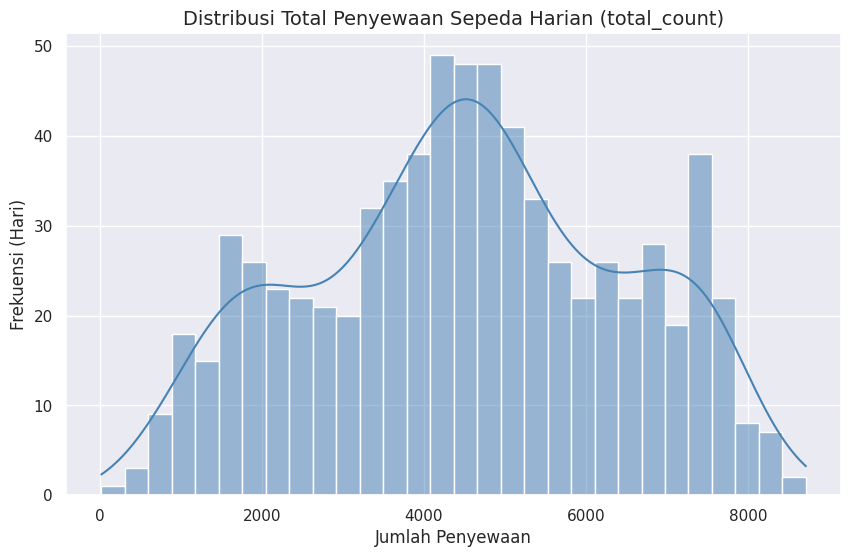

In [166]:
### Exploratory Data Analysis (EDA) - Eksplorasi Umum

# 1. Melihat Distribusi Target Variabel (Total Penyewaan Harian)
plt.figure(figsize=(10, 6))
sns.histplot(day_df['total_count'], bins=30, kde=True, color='steelblue')
plt.title('Distribusi Total Penyewaan Sepeda Harian (total_count)', fontsize=14)
plt.xlabel('Jumlah Penyewaan', fontsize=12)
plt.ylabel('Frekuensi (Hari)', fontsize=12)
plt.show()

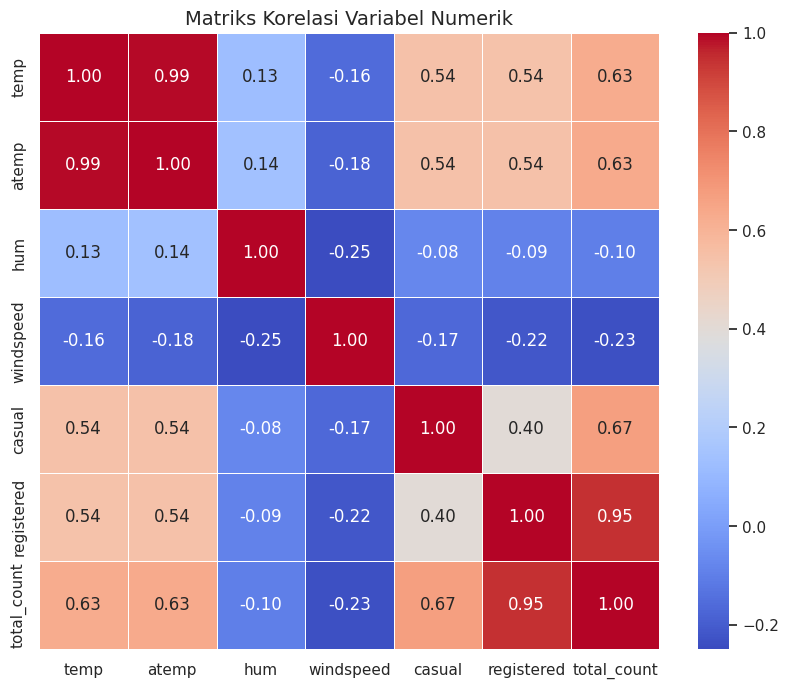

In [167]:
# 2. Analisis Korelasi Antar Variabel Numerik (Suhu, Kelembapan, Kecepatan Angin, dll)
# Memilih hanya kolom numerik yang relevan
numerical_cols = ['temp', 'atemp', 'hum', 'windspeed', 'casual', 'registered', 'total_count']
corr_matrix = day_df[numerical_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Matriks Korelasi Variabel Numerik', fontsize=14)
plt.show()

In [168]:
# 3. Rangkuman Agregasi Dasar (Berdasarkan Musim dan Cuaca)
print("=> Rata-rata Penyewaan Berdasarkan Musim:")
display(day_df.groupby('season')[['casual', 'registered', 'total_count']].mean().sort_values(by='total_count', ascending=False))

=> Rata-rata Penyewaan Berdasarkan Musim:


,casual,registered,total_count
season,,,
Fall,1202.611702,4441.691489,5644.303191
Summer,1106.097826,3886.233696,4992.331522
Winter,729.112360,3999.050562,4728.162921
Spring,334.928177,2269.204420,2604.132597


**Insight:**
- **Distribusi Penyewaan Mendekati Normal (Normal Distribution**):
Berdasarkan histogram, distribusi jumlah penyewaan harian (total_count) cenderung menyebar menyerupai kurva lonceng (mendekati distribusi normal) dengan puncak frekuensi (modus) berada di kisaran 4000 hingga 5000 penyewaan per hari. Ini menunjukkan bahwa bisnis berjalan stabil tanpa adanya outlier ekstrem yang mendominasi data harian.
- **Korelasi Suhu (Temperature) Sangat Kuat**:
Dari matriks korelasi (Heatmap), variabel suhu (temp dan suhu yang dirasakan atau atemp) memiliki korelasi positif yang paling kuat terhadap total penyewaan (total_count), yaitu sekitar 0.63. Artinya, semakin hangat suhu udara, semakin banyak orang yang menyewa sepeda. Sebaliknya, kelembapan udara (hum) dan kecepatan angin (windspeed) memiliki korelasi negatif yang lemah hingga sedang; yang berarti kelembapan tinggi dan angin kencang cenderung sedikit menurunkan minat bersepeda.

## Visualization & Explanatory Analysis

### Pertanyaan 1:

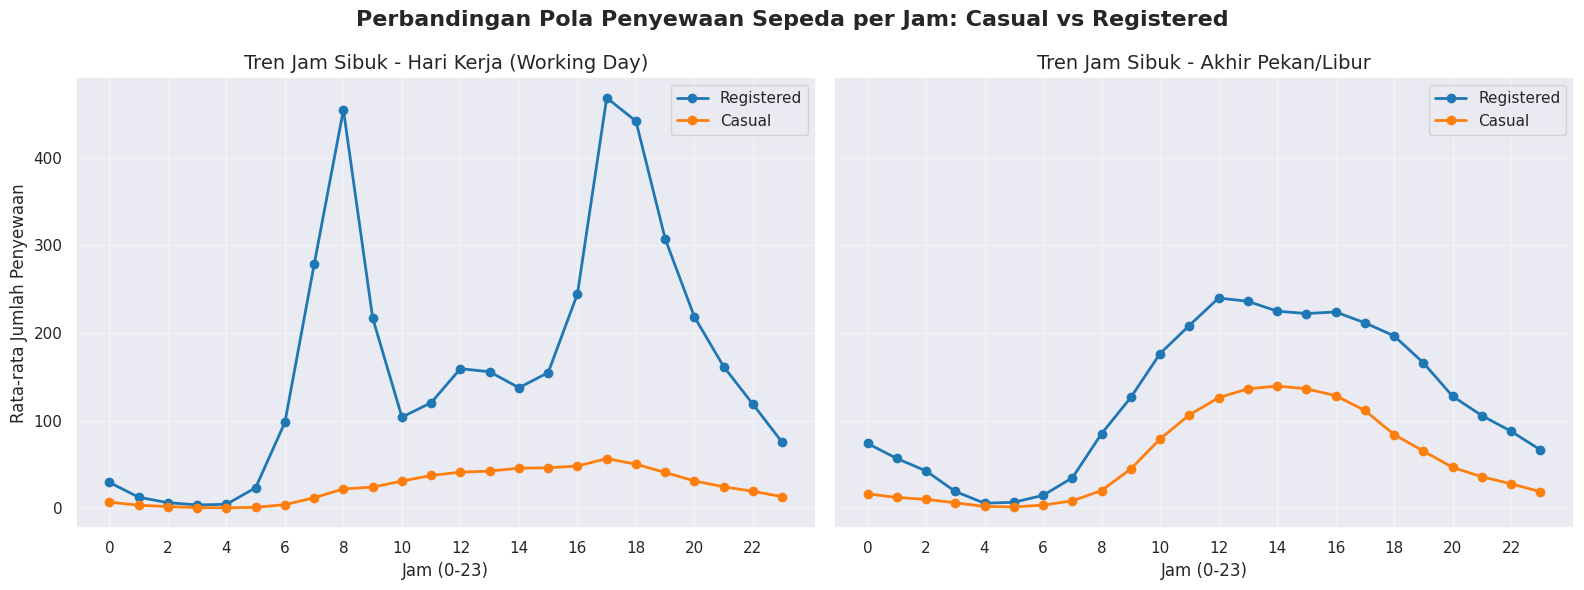

In [169]:
### Visualisasi Pertanyaan 1: Tren Jam Sibuk Casual vs Registered

# Melakukan agregasi rata-rata penyewaan per jam berdasarkan tipe hari
hourly_trend = hour_df.groupby(['workingday', 'hour'])[['casual', 'registered']].mean().reset_index()

# Menyiapkan canvas (figure) dengan 2 subplot (kiri dan kanan)
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(16, 6), sharey=True)

# 1A. Plot untuk Hari Kerja (Working Day)
working_data = hourly_trend[hourly_trend['workingday'] == 'Working Day']
axes[0].plot(working_data['hour'], working_data['registered'], label='Registered', color='#1f77b4', marker='o', linewidth=2)
axes[0].plot(working_data['hour'], working_data['casual'], label='Casual', color='#ff7f0e', marker='o', linewidth=2)
axes[0].set_title('Tren Jam Sibuk - Hari Kerja (Working Day)', fontsize=14)
axes[0].set_xlabel('Jam (0-23)', fontsize=12)
axes[0].set_ylabel('Rata-rata Jumlah Penyewaan', fontsize=12)
axes[0].set_xticks(range(0, 24, 2))
axes[0].legend()
axes[0].grid(True, alpha=0.4)

# 1B. Plot untuk Akhir Pekan/Libur (Holiday/Weekend)
holiday_data = hourly_trend[hourly_trend['workingday'] == 'Holiday/Weekend']
axes[1].plot(holiday_data['hour'], holiday_data['registered'], label='Registered', color='#1f77b4', marker='o', linewidth=2)
axes[1].plot(holiday_data['hour'], holiday_data['casual'], label='Casual', color='#ff7f0e', marker='o', linewidth=2)
axes[1].set_title('Tren Jam Sibuk - Akhir Pekan/Libur', fontsize=14)
axes[1].set_xlabel('Jam (0-23)', fontsize=12)
axes[1].set_xticks(range(0, 24, 2))
axes[1].legend()
axes[1].grid(True, alpha=0.4)

# Menambahkan judul utama
plt.suptitle('Perbandingan Pola Penyewaan Sepeda per Jam: Casual vs Registered', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

### Pertanyaan 2:

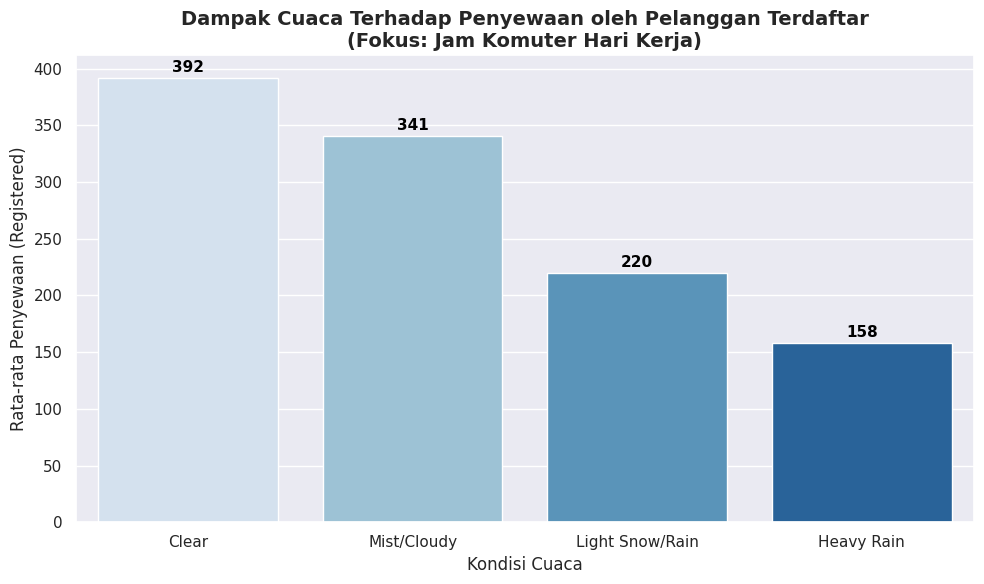

In [177]:
### Visualisasi Pertanyaan 2: Dampak Cuaca pada Jam Komuter

# Memfilter data hanya untuk jam komuter (07:00-09:00 dan 17:00-19:00) di hari kerja
commuter_hours = [7, 8, 9, 17, 18, 19]
commuter_data = hour_df[(hour_df['hour'].isin(commuter_hours)) & (hour_df['workingday'] == 'Working Day')]

# Agregasi rata-rata penyewaan oleh pelanggan 'registered' berdasarkan kondisi cuaca
weather_impact = commuter_data.groupby('weather_condition')['registered'].mean().reset_index()
weather_impact = weather_impact.sort_values(by='registered', ascending=False)

# Membuat Bar Chart
plt.figure(figsize=(10, 6))
sns.barplot(x='weather_condition', y='registered', data=weather_impact, palette='Blues')

plt.title('Dampak Cuaca Terhadap Penyewaan oleh Pelanggan Terdaftar\n(Fokus: Jam Komuter Hari Kerja)', fontsize=14, fontweight='bold')
plt.xlabel('Kondisi Cuaca', fontsize=12)
plt.ylabel('Rata-rata Penyewaan (Registered)', fontsize=12)

# Menambahkan label angka numerik di atas setiap bar grafik
for index, row in enumerate(weather_impact['registered']):
    plt.text(index, row + 5, f'{round(row)}', color='black', ha="center", fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

**Insight:**
- **Pertanyaan 1**:
Pengguna terdaftar (registered) mendominasi penyewaan dengan pola bimodal (dua puncak lonjakan tajam). Lonjakan pertama terjadi pada pukul 08:00 pagi (jam berangkat kerja), dan lonjakan kedua terjadi pada pukul 17:00-18:00 sore (jam pulang kerja). Di sisi lain, pengguna casual jumlahnya sangat sedikit dan cenderung datar sepanjang hari kerja.
- **Pertanyaan 2**:
Meskipun berada di jam-jam paling sibuk atau genting (jam berangkat dan pulang kerja), pelanggan tetap (registered) ternyata sangat sensitif terhadap perubahan cuaca.

## Analisis Lanjutan (Opsional)

Tabel Hasil Clustering Berdasarkan Suhu Udara:


,temp_cluster,casual,registered,total_count
0,Dingin (Cold),132.619048,1570.555556,1703.174603
1,Sejuk (Mild),584.342105,3174.111842,3758.453947
2,Hangat (Warm),1210.733119,4436.369775,5647.102894
3,Panas (Hot),1084.603774,4322.188679,5406.792453


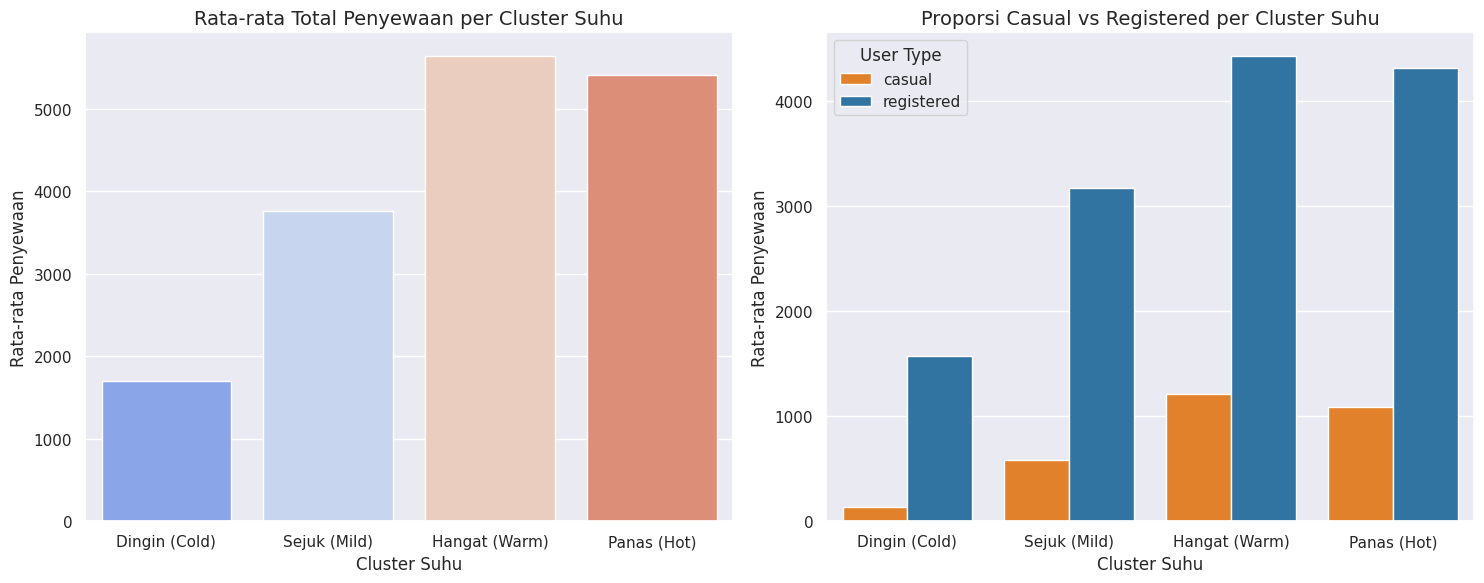

In [171]:
### Analisis Lanjutan: Clustering (Manual Grouping / Binning)

# Pada dataset, nilai suhu ('temp') sudah dinormalisasi menjadi skala 0 - 1.
# Kita akan menggunakan teknik Binning untuk membaginya ke dalam 4 Cluster Suhu.
bins = [0, 0.25, 0.50, 0.75, 1.0]
labels = ['Dingin (Cold)', 'Sejuk (Mild)', 'Hangat (Warm)', 'Panas (Hot)']

# Membuat kolom baru 'temp_cluster' menggunakan fungsi pd.cut()
day_df['temp_cluster'] = pd.cut(day_df['temp'], bins=bins, labels=labels, include_lowest=True)

# Melakukan agregasi rata-rata penyewaan berdasarkan cluster suhu
cluster_summary = day_df.groupby('temp_cluster')[['casual', 'registered', 'total_count']].mean().reset_index()

# Menampilkan tabel hasil clustering
print("Tabel Hasil Clustering Berdasarkan Suhu Udara:")
display(cluster_summary)

# Visualisasi Hasil Clustering
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(15, 6))

# Grafik 1: Total Penyewaan berdasarkan Cluster Suhu
sns.barplot(x='temp_cluster', y='total_count', data=cluster_summary, palette='coolwarm', ax=axes[0])
axes[0].set_title('Rata-rata Total Penyewaan per Cluster Suhu', fontsize=14)
axes[0].set_xlabel('Cluster Suhu', fontsize=12)
axes[0].set_ylabel('Rata-rata Penyewaan', fontsize=12)

# Grafik 2: Perbandingan Casual vs Registered di tiap Cluster
cluster_summary_melted = cluster_summary.melt(id_vars='temp_cluster', value_vars=['casual', 'registered'],
                                              var_name='User Type', value_name='Average Count')

sns.barplot(x='temp_cluster', y='Average Count', hue='User Type', data=cluster_summary_melted, palette=['#ff7f0e', '#1f77b4'], ax=axes[1])
axes[1].set_title('Proporsi Casual vs Registered per Cluster Suhu', fontsize=14)
axes[1].set_xlabel('Cluster Suhu', fontsize=12)
axes[1].set_ylabel('Rata-rata Penyewaan', fontsize=12)

plt.tight_layout()
plt.show()

## Conclusion

- Conclution pertanyaan 1 (Perbandingan Tren Jam Sibuk dan Rebalancing)

**Temuan Spesifik:** Terdapat perbedaan pola penggunaan yang sangat kontras berdasarkan tipe hari. Pada hari kerja, pengguna terdaftar (*registered*) mencapai titik **tertinggi (puncak)** pada jam komuter, yaitu pukul 08:00 pagi dan 17:00 sore. Sebaliknya, titik **terendah** penyewaan terjadi pada dini hari (pukul 03:00-04:00). Di sisi lain, pada akhir pekan/hari libur, pengguna *casual* mendominasi dengan penyewaan **tertinggi** yang merata di siang hingga sore hari (pukul 12:00-16:00).

**Alasan (Mengapa terjadi):** Fenomena ini terjadi karena pada hari kerja, sepeda difungsikan sebagai moda transportasi utama transit (*first/last-mile*) untuk berangkat dan pulang kerja/sekolah. Sedangkan pada hari libur, sepeda beralih fungsi menjadi sarana rekreasi dan olahraga santai yang umumnya dilakukan ketika matahari sudah cukup hangat.

**Rekomendasi Operasional:** Perusahaan harus menerapkan jadwal *rebalancing* (distribusi ulang sepeda antar stasiun menggunakan truk) yang dinamis. Pada hari kerja, pastikan ketersediaan sepeda penuh di stasiun area perumahan sebelum pukul 07:00 pagi, dan ditarik kembali ke area perkantoran sebelum pukul
16:00. Pada hari libur, fokus armada harus segera dipindahkan ke area taman kota atau pusat rekreasi sejak pukul 09:00 pagi.(12:00-16:00).


- Conclution pertanyaan 2 (Dampak Cuaca di Jam Komuter dan Strategi Bisnis)

**Temuan Spesifik:** Cuaca merupakan faktor eksternal dengan dampak paling ekstrem terhadap volume transaksi. Rata-rata penyewaan **tertinggi** di jam komuter selalu terjadi saat cuaca Cerah (*Clear/Partly Cloudy*). Namun, saat cuaca memburuk menjadi Hujan Ringan/Salju (*Light Snow/Rain*), volume penyewaan pelanggan setia (*registered*) anjlok drastis hingga **lebih dari 50%**. Bahkan, pada cuaca ekstrem (Hujan Lebat/Badai), angka penyewaan menyentuh nilai **terendah** (nyaris 0).

**Alasan (Mengapa terjadi):** Mengingat sepeda adalah kendaraan terbuka tanpa pelindung, kondisi presipitasi fisik (hujan/salju) secara langsung merusak kenyamanan dan mengancam keselamatan pengendara. Hal ini memaksa pelanggan komuter untuk segera beralih ke moda transportasi substitusi yang tertutup (seperti bus atau taksi).

**Rekomendasi Strategis:** Untuk mempertahankan retensi pengguna di jam krusial ini, perusahaan dapat mengintegrasikan *Weather API* ke dalam aplikasi. Ketika terdeteksi hujan akan turun di jam komuter, sistem dapat mengirimkan notifikasi *Push Promo* (misalnya: "Diskon Cuaca Buruk 40%") untuk memicu loyalitas pengguna yang ragu. Selain itu, perusahaan bisa mempertimbangkan penyediaan fasilitas tambahan seperti penyewaan jas hujan portabel di stasiun-stasiun utama.